First model submission (Model 1 – Random Forest non-linear regression)

Step 1 – Import Libraries

In [1]:
# Step 1: Imports for Model 1
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder


Step 2 – Load Kaggle datasets

In [2]:
# Step 2: Load Kaggle data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train.head()


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


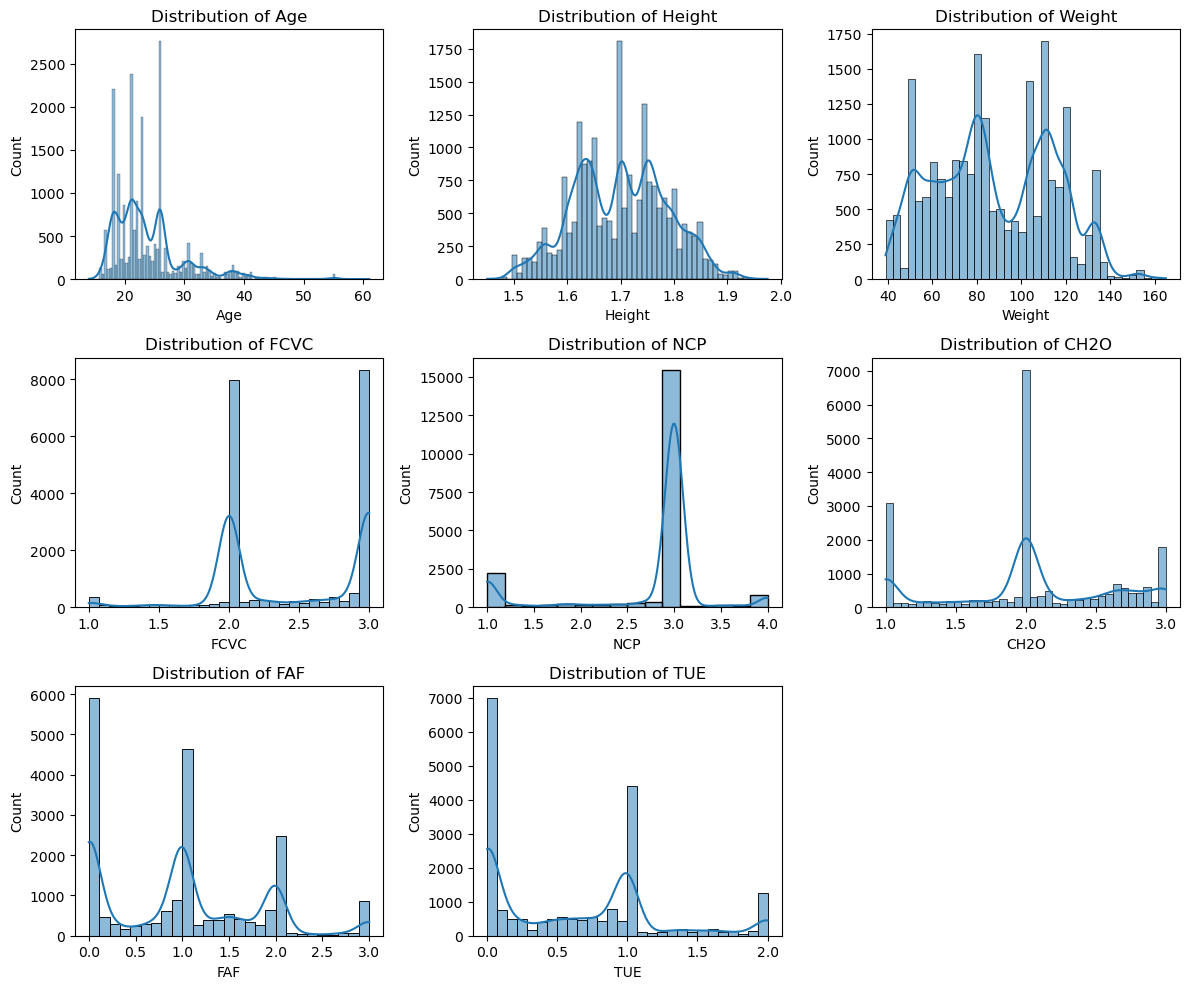

In [3]:
# 3. EDA + Figures Distribution Plots / Warning

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

import os
import matplotlib.pyplot as plt
import seaborn as sns

# 3. EDA + Figures Distribution Plots
numeric_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

# Automatically creates the "figures" folder if it doesn't exist yet
os.makedirs("NU/DDS8555/Build_Non-Linear_Models_Part 2/figures", exist_ok=True)


plt.figure(figsize=(12, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.savefig("NU/DDS8555/Build_Non-Linear_Models_Part 2/figures/model1_eda_distributions.png")
plt.show()

Step 4 — Basic EDA + Missing Data Check

In [4]:
# Step 4: Quick EDA
print(train.info())
print(train.describe())

print("Missing values in train:")
print(train.isna().sum())

print("Missing values in test:")
print(test.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

Step 5 — Encode Categorical Variables

In [5]:
#5 fit the encoder on the combined unique values of both the train and test sets. 
# This ensures the encoder learns every possible category beforehand

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 5: Encode categorical features BEFORE splitting
cat_cols = train.select_dtypes(include=["object"]).columns

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    
    if col in test.columns:
        # FIX: Combine unique values from both train and test so 'Always' is recognized
        combined_categories = pd.concat([train[col], test[col]]).dropna().unique()
        le.fit(combined_categories)
        
        # Transform both datasets safely
        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])
    else:
        # For columns ONLY in train (like your target variable 'NObeyesdad')
        train[col] = le.fit_transform(train[col])
        
    label_encoders[col] = le


Step 6 — Create Features, Target, and Validation Split

In [6]:
# Step 6: Encode categorical features BEFORE splitting
cat_cols = train.select_dtypes(include=["object"]).columns

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])
    label_encoders[col] = le


Step 7 — Fit Non‑Linear Model 1 (Random Forest)

In [7]:
# Step 7: Define features and target

target_col = "NObeyesdad"

X = train.drop(columns=[target_col])
y = train[target_col]

X_test = test.copy()

# Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# Step 8: Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Validation predictions + RMSLE
y_valid_pred = rf_model.predict(X_valid)
rmsle_rf = np.sqrt(mean_squared_log_error(y_valid, y_valid_pred))
print("Model 1 - Random Forest RMSLE (validation):", rmsle_rf)



Model 1 - Random Forest RMSLE (validation): 0.2289190454631347


Step 9 — Retrain Random Forest on Full Training Data

In [9]:
# Step 9: Retrain on full training data
rf_model_full = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model_full.fit(X, y)

# Predict on Kaggle test set
test_pred_rf = rf_model_full.predict(X_test)


Step 10 — Build First Submission File

In [10]:
# Step 10: Create first submission DataFrame
submission_rf = sample_submission.copy()
submission_rf["Rings"] = test_pred_rf

# Save CSV for Kaggle
submission_rf.to_csv("NU/DDS8555/Build_Non-Linear_Models_Part 2/submission/submission_model1_random_forest.csv", index=False)

submission_rf.head()


,id,NObeyesdad,Rings
0,20758,Normal_Weight,3.0000
1,20759,Normal_Weight,4.1600
2,20760,Normal_Weight,4.0000
3,20761,Normal_Weight,2.2775
4,20762,Normal_Weight,4.0000
